# XGBoost

### Import needed libraries

In [31]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb


### Initialize dataframes with aggregate data

In [32]:
phy30sdf = pd.read_csv('/Users/tatum/Downloads/testbed_system_1_aggregates/phys_agg_30s.csv', encoding="utf-8-sig")
phy16sdf = pd.read_csv('/Users/tatum/Downloads/testbed_system_1_aggregates/phys_agg_16s.csv', encoding="utf-8-sig")
phy10sdf = pd.read_csv('/Users/tatum/Downloads/testbed_system_1_aggregates/phys_agg_10s.csv', encoding="utf-8-sig")
scada30sdf = pd.read_csv('/Users/tatum/Downloads/testbed_system_1_aggregates/scada_agg_30s.csv', encoding="utf-8-sig")
scada16sdf = pd.read_csv('/Users/tatum/Downloads/testbed_system_1_aggregates/scada_agg_16s.csv', encoding="utf-8-sig")
scada10sdf = pd.read_csv('/Users/tatum/Downloads/testbed_system_1_aggregates/scada_agg_10s.csv', encoding="utf-8-sig")

comb30sdf = pd.concat([phy30sdf, scada30sdf], ignore_index= True)
comb16sdf = pd.concat([phy16sdf, scada16sdf], ignore_index= True)
comb10sdf = pd.concat([phy10sdf, scada10sdf], ignore_index= True)


## Train a regression model for the 30 second time frame

### Extract feature and target arrays

In [33]:
X, y = comb16sdf.drop('num_attacks', axis=1), comb16sdf[['num_attacks']]

### Convert text features to categories

In [34]:
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

for col in cat_cols:
    X[col] = X[col].astype('category')

### Split the data

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Convert into DMatrix

In [36]:
dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True)

### Define hyperparameters

In [37]:
params = {"objective": "reg:squarederror", "tree_method": "hist"}

### Train the model

In [38]:
n = 1000
model = xgb.train(
   params=params,
   dtrain=dtrain_reg,
   num_boost_round=n,
)

preds = model.predict(dtest_reg)

### Cross validate

In [39]:
params = {"objective": "reg:squarederror", "tree_method": "hist"}

results = xgb.cv(
   params, dtrain_reg,
   num_boost_round=n,
   nfold=5,
   early_stopping_rounds=39
)

### Inspect CV results object

In [40]:
print('results columns:', list(results.columns))
print(results.head())

results columns: ['train-rmse-mean', 'train-rmse-std', 'test-rmse-mean', 'test-rmse-std']
   train-rmse-mean  train-rmse-std  test-rmse-mean  test-rmse-std
0      2371.257053      200.296490     2116.503833    1247.312515
1      1870.226967      131.436437     1751.123849     984.592441
2      1477.780951       83.327927     1467.813466     780.892905
3      1170.158728       50.537166     1246.629380     631.883287
4       929.372385       29.028479     1074.472356     528.056725


### Find the 

In [41]:
y_test_arr = y_test.values.ravel() if hasattr(y_test, 'values') else np.asarray(y_test).ravel()
mse = mean_squared_error(y_test_arr, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_arr, preds)
print(f'MSE: {mse:.4f}, RMSE: {rmse:.4f}, R^2: {r2:.4f}')

MSE: 197115.0469, RMSE: 443.9764, R^2: 0.3735


### predicted vs actual scatter

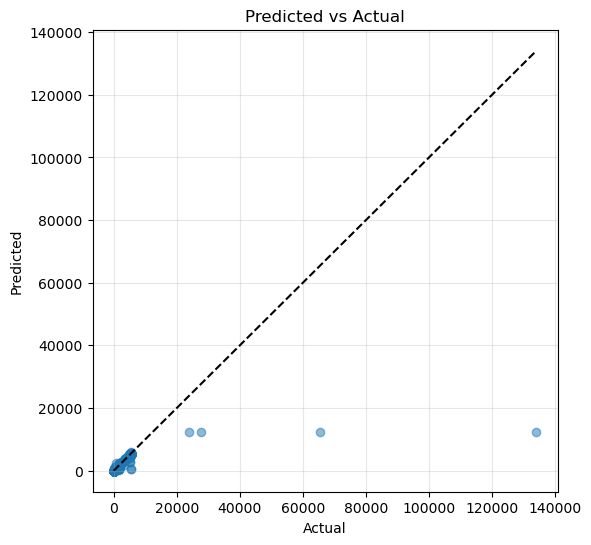

In [42]:
# Diagnostic: ensure preds and y_test are present and aligned (auto-recompute if possible)
import numpy as np
def _ensure_preds_aligned():
    global preds
    # get y array
    if 'y_test_arr' in globals():
        y_arr = np.asarray(y_test_arr)
    elif 'y_test' in globals():
        y_arr = np.asarray(y_test.values.ravel()) if hasattr(y_test, 'values') else np.asarray(y_test).ravel()
    else:
        raise RuntimeError('y_test not found - run the split cell first')
    # get preds if present
    preds_arr = np.asarray(preds) if 'preds' in globals() else None
    # if missing or mismatched, try to recompute from current model+dtest_reg
    if preds_arr is None or preds_arr.shape[0] != y_arr.shape[0]:
        if 'model' in globals() and 'dtest_reg' in globals():
            preds_re = model.predict(dtest_reg)
            preds_arr = np.asarray(preds_re)
            preds = preds_re
            print(f'Recomputed preds from model/dtest_reg: {preds_arr.shape[0]} rows')
        else:
            raise RuntimeError(f'length mismatch or missing preds (preds={None if preds_arr is None else preds_arr.shape[0]} vs y_test={y_arr.shape[0]}). Run the training/predict cells for this section so `preds` and `y_test` are defined and aligned.')
    if preds_arr.shape[0] != y_arr.shape[0]:
        raise RuntimeError(f'length mismatch after recompute: preds={preds_arr.shape[0]} vs y_test={y_arr.shape[0]} - re-run split/predict to align')
    # drop paired NaNs for plotting
    mask = ~np.isnan(preds_arr) & ~np.isnan(y_arr.astype(float))
    preds_plot = preds_arr[mask]
    y_plot = y_arr[mask]
    return y_plot, preds_plot
y_plot, preds_plot = _ensure_preds_aligned()
plt.figure(figsize=(6,6))
plt.scatter(y_plot, preds_plot, alpha=0.5)
lims = [min(y_plot.min(), preds_plot.min()), max(y_plot.max(), preds_plot.max())]
plt.plot(lims, lims, color='k', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual')
plt.grid(alpha=0.3)
plt.show()

## Repeat for the 16 second time frame

### Extract feature and target arrays

In [43]:
X, y = comb16sdf.drop('num_attacks', axis=1), comb16sdf[['num_attacks']]

### Convert text features to categories

In [44]:
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

for col in cat_cols:
    X[col] = X[col].astype('category')

### Split the data

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Convert into DMatrix

In [46]:
dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True)

### Define hyperparameters

In [47]:
params = {"objective": "reg:squarederror", "tree_method": "hist"}

### Train the model

In [48]:
n = 1000
model = xgb.train(
   params=params,
   dtrain=dtrain_reg,
   num_boost_round=n,
)

preds = model.predict(dtest_reg)

### Cross validate

In [49]:
params = {"objective": "reg:squarederror", "tree_method": "hist"}

results = xgb.cv(
   params, dtrain_reg,
   num_boost_round=n,
   nfold=5,
   early_stopping_rounds=39
)

### Inspect results

In [50]:
print('results columns:', list(results.columns))
print(results.head())

results columns: ['train-rmse-mean', 'train-rmse-std', 'test-rmse-mean', 'test-rmse-std']
   train-rmse-mean  train-rmse-std  test-rmse-mean  test-rmse-std
0      2371.257053      200.296490     2116.503833    1247.312515
1      1870.226967      131.436437     1751.123849     984.592441
2      1477.780951       83.327927     1467.813466     780.892905
3      1170.158728       50.537166     1246.629380     631.883287
4       929.372385       29.028479     1074.472356     528.056725


### Predicted v. actual scatter

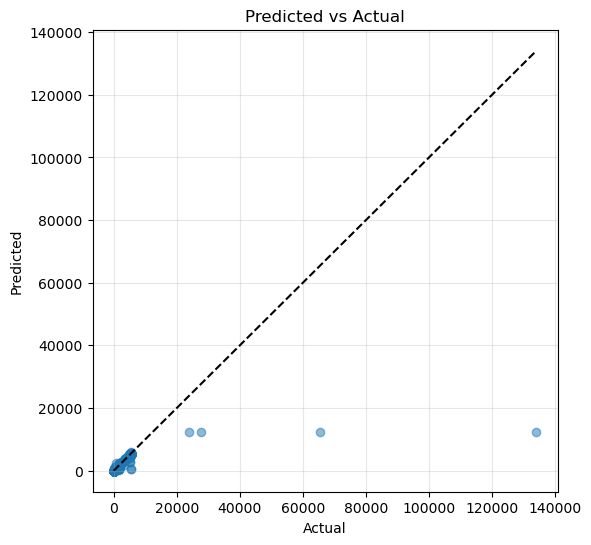

In [51]:
# Diagnostic: ensure preds and y_test are present and aligned
import numpy as np
if 'preds' not in globals():
    raise RuntimeError('preds not found - run the training/predict cells first')
if 'y_test_arr' in globals():
    y_arr = np.asarray(y_test_arr)
elif 'y_test' in globals():
    y_arr = np.asarray(y_test.values.ravel()) if hasattr(y_test, 'values') else np.asarray(y_test).ravel()
else:
    raise RuntimeError('y_test not found - run the split cell first')
preds_arr = np.asarray(preds)
if preds_arr.shape[0] != y_arr.shape[0]:
    raise RuntimeError(f'length mismatch: preds={preds_arr.shape[0]} vs y_test={y_arr.shape[0]} - re-run split/predict to align')
# drop paired NaNs for plotting
mask = ~np.isnan(preds_arr) & ~np.isnan(y_arr.astype(float))
preds_plot = preds_arr[mask]
y_plot = y_arr[mask]
plt.figure(figsize=(6,6))
plt.scatter(y_plot, preds_plot, alpha=0.5)
lims = [min(y_plot.min(), preds_plot.min()), max(y_plot.max(), preds_plot.max())]
plt.plot(lims, lims, color='k', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual')
plt.grid(alpha=0.3)
plt.show()

## Repeat for the 10 second time frame

### Extract feature and target arrays

In [52]:
X, y = comb10sdf.drop('num_attacks', axis=1), comb10sdf[['num_attacks']]

### Convert text features to categories

In [53]:
cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()

for col in cat_cols:
    X[col] = X[col].astype('category')

### Split the data

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Convert into DMatrix

In [55]:
dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True)

### Define hyperparameters

In [56]:
params = {"objective": "reg:squarederror", "tree_method": "hist"}

### Train the model

In [57]:
n = 1000
model = xgb.train(
   params=params,
   dtrain=dtrain_reg,
   num_boost_round=n,
)

preds = model.predict(dtest_reg)

### Cross validate

In [58]:
params = {"objective": "reg:squarederror", "tree_method": "hist"}

results = xgb.cv(
   params, dtrain_reg,
   num_boost_round=n,
   nfold=5,
   early_stopping_rounds=39
)

### Inspect results

In [59]:
print('results columns:', list(results.columns))
print(results.head())

results columns: ['train-rmse-mean', 'train-rmse-std', 'test-rmse-mean', 'test-rmse-std']
   train-rmse-mean  train-rmse-std  test-rmse-mean  test-rmse-std
0      1438.419349      500.495146     1306.098326     1479.50789


### Predicted v actual scatter

In [60]:
# Diagnostic: ensure preds and y_test are present and aligned
import numpy as np
if 'preds' not in globals():
    raise RuntimeError('preds not found - run the training/predict cells first')
if 'y_test_arr' in globals():
    y_arr = np.asarray(y_test_arr)
elif 'y_test' in globals():
    y_arr = np.asarray(y_test.values.ravel()) if hasattr(y_test, 'values') else np.asarray(y_test).ravel()
else:
    raise RuntimeError('y_test not found - run the split cell first')
preds_arr = np.asarray(preds)
if preds_arr.shape[0] != y_arr.shape[0]:
    raise RuntimeError(f'length mismatch: preds={preds_arr.shape[0]} vs y_test={y_arr.shape[0]} - re-run split/predict to align')
# drop paired NaNs for plotting
mask = ~np.isnan(preds_arr) & ~np.isnan(y_arr.astype(float))
preds_plot = preds_arr[mask]
y_plot = y_arr[mask]
plt.figure(figsize=(6,6))
plt.scatter(y_plot, preds_plot, alpha=0.5)
lims = [min(y_plot.min(), preds_plot.min()), max(y_plot.max(), preds_plot.max())]
plt.plot(lims, lims, color='k', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual')
plt.grid(alpha=0.3)
plt.show()

RuntimeError: length mismatch: preds=102498 vs y_test=91812 - re-run split/predict to align